In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
from scipy.sparse import hstack

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

sns.set(style="whitegrid")
%matplotlib inline

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


In [2]:
train = pd.read_csv('/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/train.csv.zip')

print(f"Размер датасета: {train.shape}")
print(f"\nКолонки: {train.columns.tolist()}")
print(f"\nТипы данных:\n{train.dtypes}")
print(f"\nПропуски:\n{train.isnull().sum()}")
train.head(3)

Размер датасета: (159571, 8)

Колонки: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Типы данных:
id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

Пропуски:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


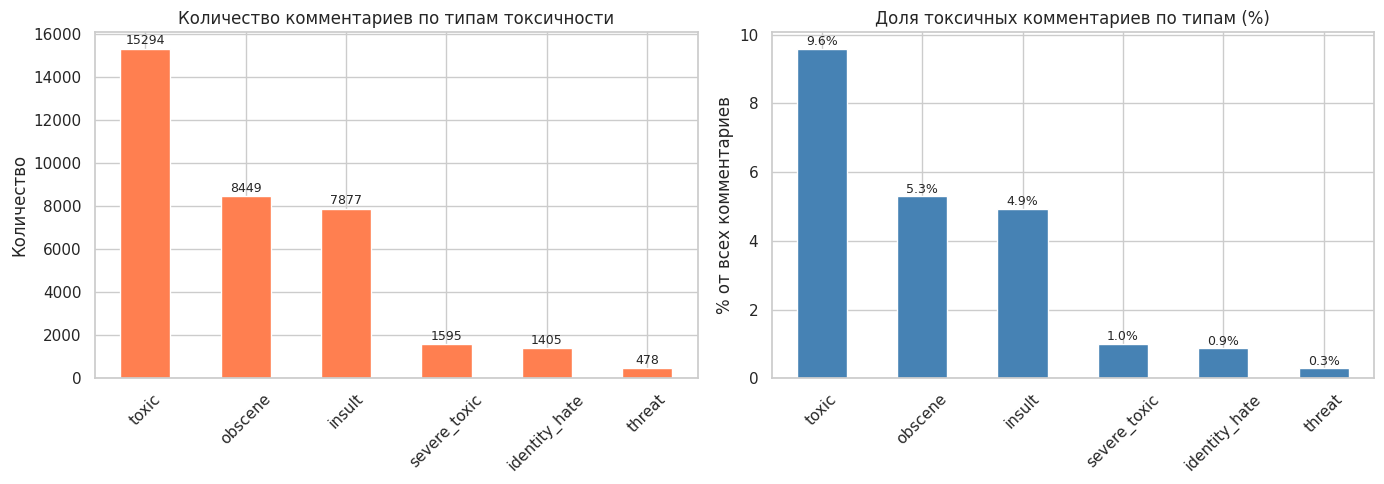

Всего комментариев: 159571
Чистых (без токсичности): 143346 (89.8%)
Токсичных (хотя бы 1 метка): 16225 (10.2%)


In [3]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

label_counts = train[label_cols].sum().sort_values(ascending=False)
label_pcts = (train[label_cols].mean() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Количество комментариев по типам токсичности')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 200, str(v), ha='center', fontsize=9)

label_pcts.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Доля токсичных комментариев по типам (%)')
axes[1].set_ylabel('% от всех комментариев')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(label_pcts):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

total = len(train)
toxic_any = train[label_cols].max(axis=1).sum()
clean = total - toxic_any
print(f"Всего комментариев: {total}")
print(f"Чистых (без токсичности): {clean} ({clean/total*100:.1f}%)")
print(f"Токсичных (хотя бы 1 метка): {int(toxic_any)} ({toxic_any/total*100:.1f}%)")

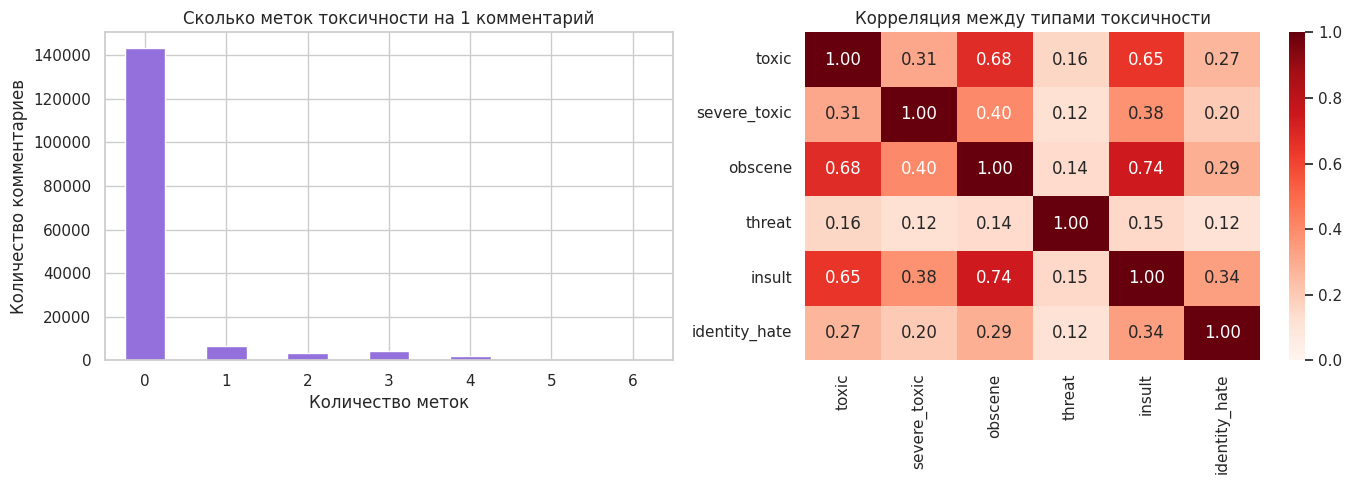

Распределение количества меток:
  0 меток: 143346 (89.8%)
  1 меток: 6360 (4.0%)
  2 меток: 3480 (2.2%)
  3 меток: 4209 (2.6%)
  4 меток: 1760 (1.1%)
  5 меток: 385 (0.2%)
  6 меток: 31 (0.0%)


In [4]:
# Количество меток на один комментарий
train['label_count'] = train[label_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение количества меток
train['label_count'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Сколько меток токсичности на 1 комментарий')
axes[0].set_xlabel('Количество меток')
axes[0].set_ylabel('Количество комментариев')
axes[0].tick_params(axis='x', rotation=0)

# Корреляция между типами токсичности
corr = train[label_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Корреляция между типами токсичности')

plt.tight_layout()
plt.show()

print("Распределение количества меток:")
for i in range(7):
    cnt = (train['label_count'] == i).sum()
    print(f"  {i} меток: {cnt} ({cnt/len(train)*100:.1f}%)")

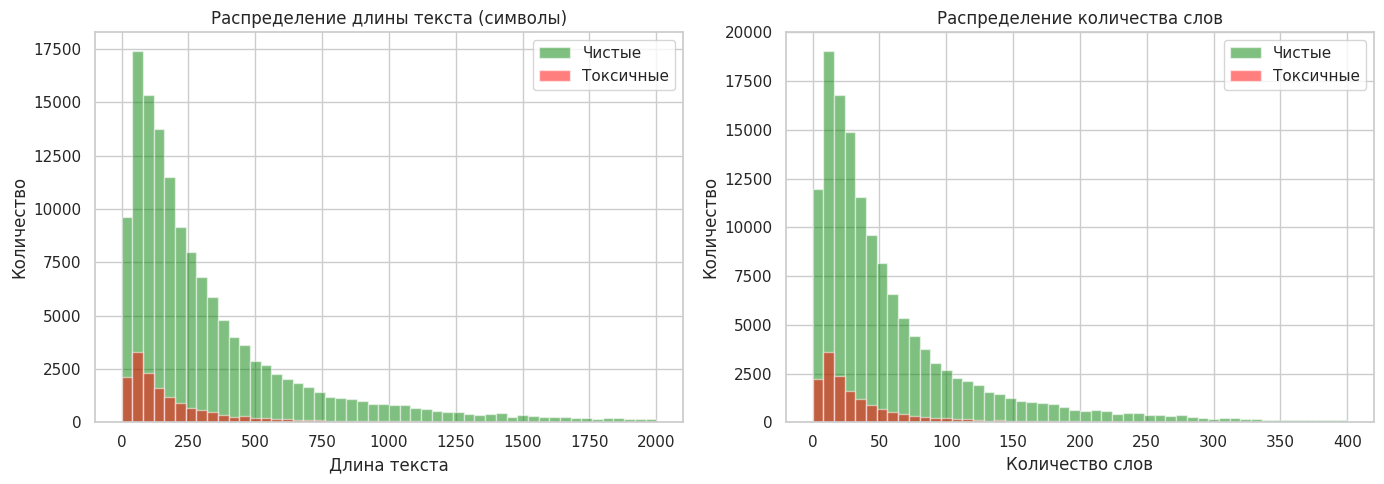

Средняя длина текста:
  Чистые: 404 символов, 69 слов
  Токсичные: 303 символов, 53 слов


In [5]:
train['text_length'] = train['comment_text'].str.len()
train['word_count'] = train['comment_text'].str.split().str.len()

train['is_toxic'] = train[label_cols].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, 'green', 'Чистые'), (1, 'red', 'Токсичные')]:
    subset = train[train['is_toxic'] == label]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.5, color=color, label=name, range=(0, 2000))
axes[0].set_title('Распределение длины текста (символы)')
axes[0].set_xlabel('Длина текста')
axes[0].set_ylabel('Количество')
axes[0].legend()

for label, color, name in [(0, 'green', 'Чистые'), (1, 'red', 'Токсичные')]:
    subset = train[train['is_toxic'] == label]['word_count']
    axes[1].hist(subset, bins=50, alpha=0.5, color=color, label=name, range=(0, 400))
axes[1].set_title('Распределение количества слов')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Средняя длина текста:")
print(f"  Чистые: {train[train['is_toxic']==0]['text_length'].mean():.0f} символов, {train[train['is_toxic']==0]['word_count'].mean():.0f} слов")
print(f"  Токсичные: {train[train['is_toxic']==1]['text_length'].mean():.0f} символов, {train[train['is_toxic']==1]['word_count'].mean():.0f} слов")

In [6]:
print("Примеры ЧИСТЫХ комментариев \n")
for text in train[train['is_toxic'] == 0].sample(3, random_state=42)['comment_text'].values:
    print(text[:200])
    print("---")

print("\nПримеры ТОКСИЧНЫХ комментариев\n")
for text in train[train['is_toxic'] == 1].sample(3, random_state=42)['comment_text'].values:
    print(text[:200])
    print("---")

Примеры ЧИСТЫХ комментариев 

"

Oh, don't worry about me, Sandstein. I'm of no strong opinion as to what is ""well."" Editing Wikipedia is not a personal benefit; if it were, I'd be COI! I do have some unfinished business, both w
---
Are you trying to dispute that fact?
---
SWOT analysis 

This source – Align Technology, Inc. SWOT Analysis. (2013). 1-8. – is used 11 times, with no indication of how to find it or whether it's a primary source (I assume it is), so I'm goin
---

Примеры ТОКСИЧНЫХ комментариев

"
I was talking about them running any check they want on ME to disprove your claims.  I didn't know where you lived until you were silly enough to post an IP and connect your name to it. And yes you 
---
White Trash
Fuck off you white piece of trash. Fucking wiggers. Go and fuck a Jew, Jew raper.
---
eat shit get rid of goofs you queers.
---


In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text) 
    text = re.sub(r'[^a-zA-Z\s]', '', text) 
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

print("Запуск очистки текста...")
train['cleaned_text'] = train['comment_text'].apply(preprocess_text)
print("Готово.")
print(f"\nПример до: {train['comment_text'].iloc[0][:150]}")
print(f"\nПример после: {train['cleaned_text'].iloc[0][:150]}")

Запуск очистки текста...
Готово.

Пример до: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted

Пример после: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk 


In [8]:
train['text_length'] = train['comment_text'].str.len()

train['word_count'] = train['comment_text'].str.split().str.len()

train['avg_word_length'] = train['text_length'] / (train['word_count'] + 1)

train['uppercase_ratio'] = train['comment_text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))

train['exclamation_count'] = train['comment_text'].str.count('!')

train['question_count'] = train['comment_text'].str.count(r'\?')

# (низкая возможно = повторение оскорблений)
train['unique_word_ratio'] = train['comment_text'].apply(
    lambda x: len(set(str(x).lower().split())) / (len(str(x).lower().split()) + 1))

train['punctuation_count'] = train['comment_text'].apply(
    lambda x: sum(1 for c in str(x) if c in '.,;:!?-()[]{}"\'/\\'))

train['has_url'] = train['comment_text'].apply(
    lambda x: 1 if re.search(r'http|www|\.com|\.org', str(x)) else 0)

# ПОЛНОСТЬЮ КАПСОМ
train['capital_word_count'] = train['comment_text'].apply(
    lambda x: sum(1 for word in str(x).split() if word.isupper() and len(word) > 1))

train['sentence_count'] = train['comment_text'].apply(
    lambda x: max(len(re.split(r'[.!?]+', str(x))) - 1, 1))

feature_cols = ['text_length', 'word_count', 'avg_word_length', 'uppercase_ratio',
                'exclamation_count', 'question_count', 'unique_word_ratio',
                'punctuation_count', 'has_url', 'capital_word_count', 'sentence_count']

print(f"Создано {len(feature_cols)} признаков:")
print(train[feature_cols].describe().round(2))

Создано 11 признаков:
       text_length  word_count  avg_word_length  uppercase_ratio  \
count    159571.00   159571.00        159571.00        159571.00   
mean        394.07       67.27             5.66             0.05   
std         590.72       99.23             5.91             0.09   
min           6.00        1.00             1.77             0.00   
25%          96.00       17.00             5.11             0.02   
50%         205.00       36.00             5.54             0.03   
75%         435.00       75.00             5.94             0.05   
max        5000.00     1411.00          1242.25             1.00   

       exclamation_count  question_count  unique_word_ratio  \
count          159571.00       159571.00          159571.00   
mean                0.66            0.45               0.80   
std                25.90            1.59               0.11   
min                 0.00            0.00               0.00   
25%                 0.00            0.00          

Сравнение признаков: Чистые vs Токсичные комментарии

                     Чистые  Токсичные  Разница (%)
text_length         404.347    303.304        -25.0
word_count           68.921     52.718        -23.5
avg_word_length       5.652      5.761          1.9
uppercase_ratio       0.044      0.110        143.5
exclamation_count     0.343      3.473        908.5
question_count        0.434      0.588         35.5
unique_word_ratio     0.801      0.809          0.9
punctuation_count    15.385     13.788        -10.4
has_url               0.043      0.020        -52.9
capital_word_count    1.081      7.357        580.0
sentence_count        4.725      4.887          3.4


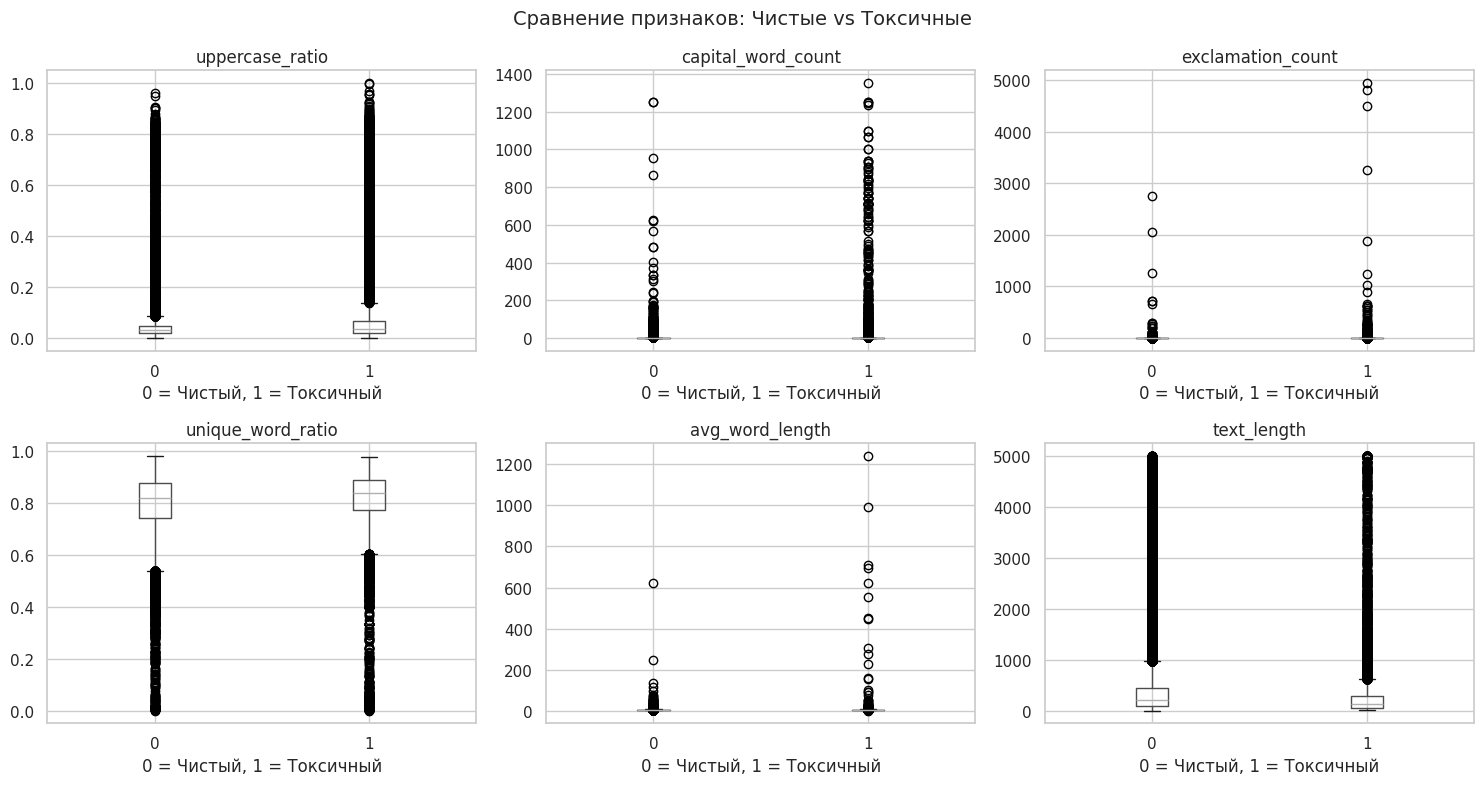

In [9]:
comparison = train.groupby('is_toxic')[feature_cols].mean().T
comparison.columns = ['Чистые', 'Токсичные']
comparison['Разница (%)'] = ((comparison['Токсичные'] - comparison['Чистые']) / (comparison['Чистые'] + 0.001) * 100).round(1)
print("Сравнение признаков: Чистые vs Токсичные комментарии\n")
print(comparison.round(3).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
most_different = ['uppercase_ratio', 'capital_word_count', 'exclamation_count',
                  'unique_word_ratio', 'avg_word_length', 'text_length']

for idx, feat in enumerate(most_different):
    ax = axes[idx // 3][idx % 3]
    train.boxplot(column=feat, by='is_toxic', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('0 = Чистый, 1 = Токсичный')

plt.suptitle('Сравнение признаков: Чистые vs Токсичные', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
print("TF-IDF")
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5)

X_tfidf = tfidf.fit_transform(train['cleaned_text'])
print(f"TF-IDF матрица: {X_tfidf.shape}")

X_features = train[feature_cols].values
from scipy.sparse import csr_matrix
X_features_sparse = csr_matrix(X_features)
X_combined = hstack([X_tfidf, X_features_sparse])
print(f"Итоговая матрица признаков: {X_combined.shape}")

y = train['is_toxic']

X_train, X_val, y_train, y_val = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nРазделение данных:")
print(f"  Train: {X_train.shape[0]} ({y_train.mean()*100:.1f}% токсичных)")
print(f"  Validation: {X_val.shape[0]} ({y_val.mean()*100:.1f}% токсичных)")

test_df = pd.read_csv('/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test.csv.zip')
test_labels_df = pd.read_csv('/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip')

# убираем строки с -1 (метки скрыты организаторами соревнования)
test_labels_clean = test_labels_df[test_labels_df['toxic'] != -1]
test_clean = test_df[test_df['id'].isin(test_labels_clean['id'])].copy()
test_clean = test_clean.merge(test_labels_clean, on='id')

print(f"\nВнешний тестовый набор: {len(test_clean)} комментариев (из {len(test_labels_df)} исходных, {len(test_labels_df) - len(test_clean)} отброшено из-за скрытых меток)")

# Предобработка внешнего теста
test_clean['cleaned_text'] = test_clean['comment_text'].apply(preprocess_text)

# Создаём те же 11 фичей
test_clean['text_length'] = test_clean['comment_text'].str.len()
test_clean['word_count'] = test_clean['comment_text'].str.split().str.len()
test_clean['avg_word_length'] = test_clean['text_length'] / (test_clean['word_count'] + 1)
test_clean['uppercase_ratio'] = test_clean['comment_text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))
test_clean['exclamation_count'] = test_clean['comment_text'].str.count('!')
test_clean['question_count'] = test_clean['comment_text'].str.count(r'\?')
test_clean['unique_word_ratio'] = test_clean['comment_text'].apply(
    lambda x: len(set(str(x).lower().split())) / (len(str(x).lower().split()) + 1))
test_clean['punctuation_count'] = test_clean['comment_text'].apply(
    lambda x: sum(1 for c in str(x) if c in '.,;:!?-()[]{}"\'/\\'))
test_clean['has_url'] = test_clean['comment_text'].apply(
    lambda x: 1 if re.search(r'http|www|\.com|\.org', str(x)) else 0)
test_clean['capital_word_count'] = test_clean['comment_text'].apply(
    lambda x: sum(1 for word in str(x).split() if word.isupper() and len(word) > 1))
test_clean['sentence_count'] = test_clean['comment_text'].apply(
    lambda x: max(len(re.split(r'[.!?]+', str(x))) - 1, 1))

X_ext_tfidf = tfidf.transform(test_clean['cleaned_text'])
X_ext_features = csr_matrix(test_clean[feature_cols].values)
X_ext_test = hstack([X_ext_tfidf, X_ext_features])

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
test_clean['is_toxic'] = test_clean[label_cols].max(axis=1)
y_ext_test = test_clean['is_toxic']

print(f"  Внешний тест: {X_ext_test.shape[0]} комментариев ({y_ext_test.mean()*100:.1f}% токсичных)")

TF-IDF
TF-IDF матрица: (159571, 15000)
Итоговая матрица признаков: (159571, 15011)

Разделение данных:
  Train: 127656 (10.2% токсичных)
  Validation: 31915 (10.2% токсичных)

Внешний тестовый набор: 63978 комментариев (из 153164 исходных, 89186 отброшено из-за скрытых меток)
  Внешний тест: 63978 комментариев (9.8% токсичных)


In [11]:
X_combined.shape

(159571, 15011)

In [12]:
print("Обучение Random Forest...")
start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start
rf_proba_val = rf_model.predict_proba(X_val)[:, 1]

# Подбираем оптимальный порог по F1-score
from sklearn.metrics import f1_score
best_rf_thresh = 0.5
best_rf_f1 = 0
for thresh in np.arange(0.3, 0.7, 0.01):
    preds = (rf_proba_val >= thresh).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_rf_f1:
        best_rf_f1 = f1
        best_rf_thresh = thresh

rf_preds_val = (rf_proba_val >= best_rf_thresh).astype(int)
print(f"Random Forest обучен за {rf_time:.1f} сек. (оптимальный порог = {best_rf_thresh:.2f})")
print(classification_report(y_val, rf_preds_val))

Обучение Random Forest...
Random Forest обучен за 657.1 сек. (оптимальный порог = 0.30)
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     28670
           1       0.80      0.72      0.76      3245

    accuracy                           0.95     31915
   macro avg       0.88      0.85      0.87     31915
weighted avg       0.95      0.95      0.95     31915



In [13]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print("Обучение XGBoost...")
start = time.time()
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start
xgb_proba_val = xgb_model.predict_proba(X_val)[:, 1]

# Подбираем оптимальный порог
best_xgb_thresh = 0.5
best_xgb_f1 = 0
for thresh in np.arange(0.3, 0.7, 0.01):
    preds = (xgb_proba_val >= thresh).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_xgb_f1:
        best_xgb_f1 = f1
        best_xgb_thresh = thresh

xgb_preds_val = (xgb_proba_val >= best_xgb_thresh).astype(int)
print(f"XGBoost обучен за {xgb_time:.1f} сек. (оптимальный порог = {best_xgb_thresh:.2f})")
print(classification_report(y_val, xgb_preds_val))

Обучение XGBoost...
XGBoost обучен за 244.5 сек. (оптимальный порог = 0.65)
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     28670
           1       0.80      0.75      0.77      3245

    accuracy                           0.95     31915
   macro avg       0.88      0.86      0.87     31915
weighted avg       0.95      0.95      0.95     31915



In [14]:
from lightgbm import LGBMClassifier

print("Обучение LightGBM...")
start = time.time()
lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_time = time.time() - start
lgbm_proba_val = lgbm_model.predict_proba(X_val)[:, 1]

best_lgbm_thresh = 0.5
best_lgbm_f1 = 0
for thresh in np.arange(0.3, 0.7, 0.01):
    preds = (lgbm_proba_val >= thresh).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_lgbm_f1:
        best_lgbm_f1 = f1
        best_lgbm_thresh = thresh

lgbm_preds_val = (lgbm_proba_val >= best_lgbm_thresh).astype(int)
print(f"LightGBM обучен за {lgbm_time:.1f} сек. (оптимальный порог = {best_lgbm_thresh:.2f})")
print(classification_report(y_val, lgbm_preds_val))

Обучение LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM обучен за 60.1 сек. (оптимальный порог = 0.64)
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     28670
           1       0.78      0.76      0.77      3245

    accuracy                           0.95     31915
   macro avg       0.88      0.87      0.87     31915
weighted avg       0.95      0.95      0.95     31915



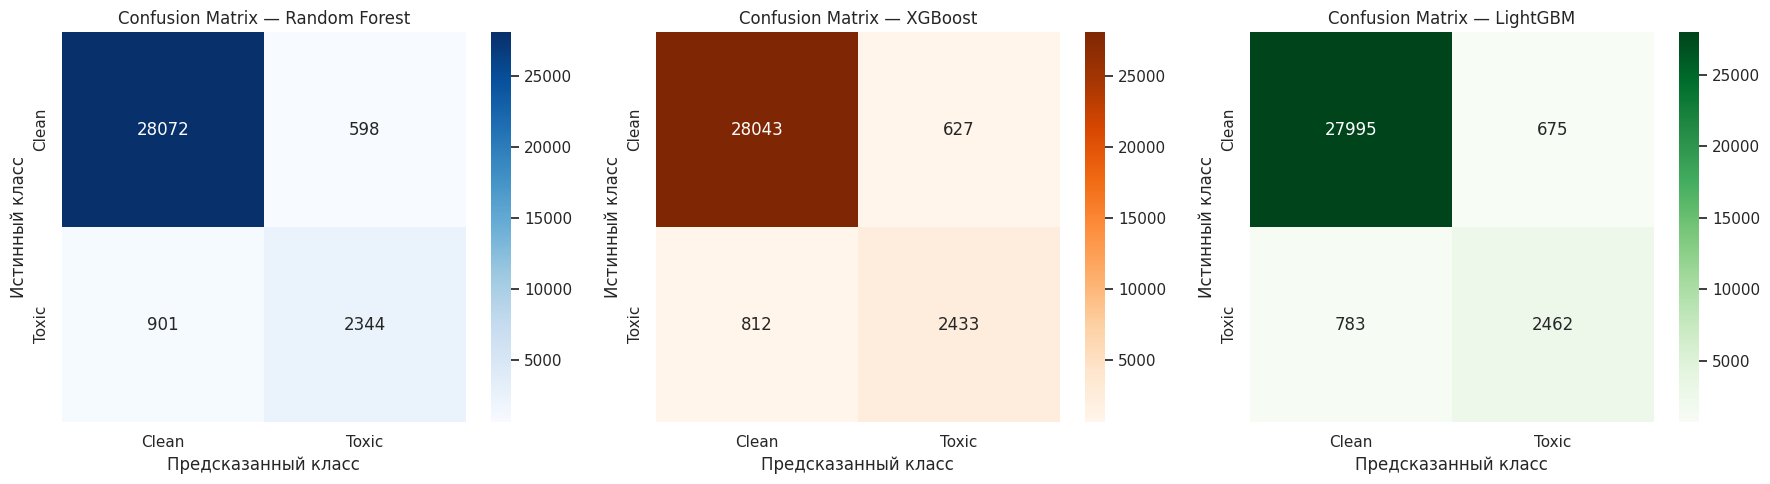

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    ('Random Forest', rf_preds_val, 'Blues'),
    ('XGBoost', xgb_preds_val, 'Oranges'),
    ('LightGBM', lgbm_preds_val, 'Greens')
]

for idx, (name, y_pred, cmap) in enumerate(models_data):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[idx],
                xticklabels=['Clean', 'Toxic'], yticklabels=['Clean', 'Toxic'])
    axes[idx].set_title(f'Confusion Matrix — {name}')
    axes[idx].set_xlabel('Предсказанный класс')
    axes[idx].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

Сравнение моделей (Validation):

       Модель  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  AUC-ROC  Время (сек)
Random Forest    0.9530             0.8828          0.8507      0.8659   0.9610     657.1463
      XGBoost    0.9549             0.8835          0.8639      0.8734   0.9594     244.4563
     LightGBM    0.9543             0.8788          0.8676      0.8731   0.9608      60.0937


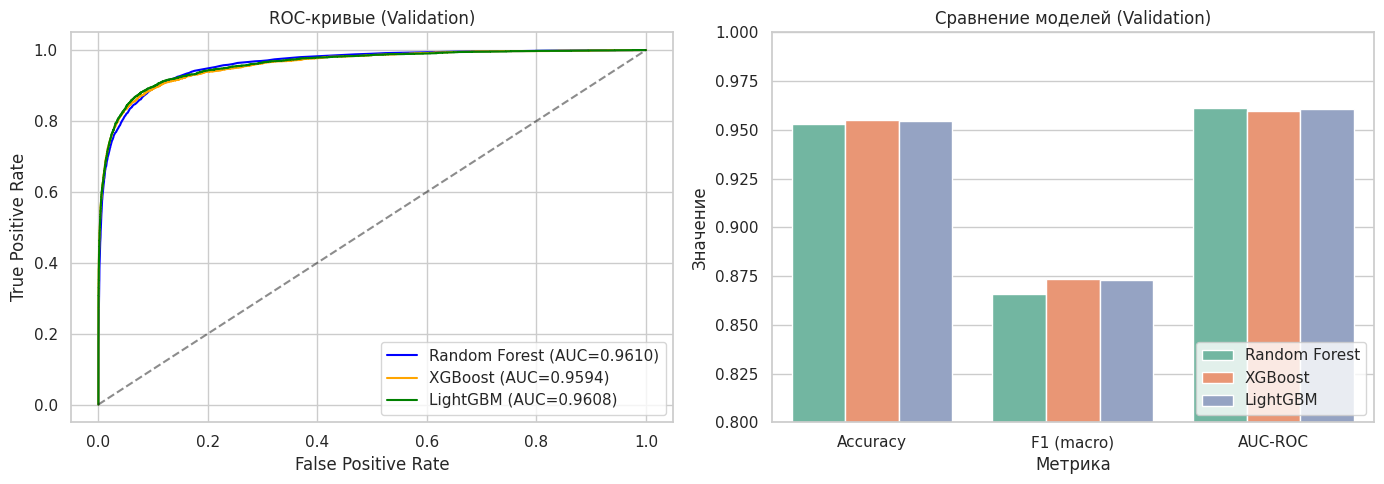

In [16]:
results = pd.DataFrame({
    'Модель': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_val, rf_preds_val),
        accuracy_score(y_val, xgb_preds_val),
        accuracy_score(y_val, lgbm_preds_val)
    ],
    'Precision (macro)': [
        precision_score(y_val, rf_preds_val, average='macro'),
        precision_score(y_val, xgb_preds_val, average='macro'),
        precision_score(y_val, lgbm_preds_val, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_val, rf_preds_val, average='macro'),
        recall_score(y_val, xgb_preds_val, average='macro'),
        recall_score(y_val, lgbm_preds_val, average='macro')
    ],
    'F1 (macro)': [
        f1_score(y_val, rf_preds_val, average='macro'),
        f1_score(y_val, xgb_preds_val, average='macro'),
        f1_score(y_val, lgbm_preds_val, average='macro')
    ],
    'AUC-ROC': [
        roc_auc_score(y_val, rf_proba_val),
        roc_auc_score(y_val, xgb_proba_val),
        roc_auc_score(y_val, lgbm_proba_val)
    ],
    'Время (сек)': [rf_time, xgb_time, lgbm_time]
}).round(4)

print("Сравнение моделей (Validation):\n")
print(results.to_string(index=False))

# ROC-кривые и барплот
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba, color in [('Random Forest', rf_proba_val, 'blue'),
                            ('XGBoost', xgb_proba_val, 'orange'),
                            ('LightGBM', lgbm_proba_val, 'green')]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC-кривые (Validation)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

results_melted = results[['Модель', 'Accuracy', 'F1 (macro)', 'AUC-ROC']].melt(
    id_vars='Модель', var_name='Метрика', value_name='Значение')
sns.barplot(data=results_melted, x='Метрика', y='Значение', hue='Модель', palette='Set2', ax=axes[1])
axes[1].set_title('Сравнение моделей (Validation)')
axes[1].set_ylim(0.8, 1.0)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [17]:
print("=== Финальная проверка на внешнем тесте (test.csv) ===\n")

rf_proba_ext = rf_model.predict_proba(X_ext_test)[:, 1]
rf_preds_ext = (rf_proba_ext >= best_rf_thresh).astype(int)

xgb_proba_ext = xgb_model.predict_proba(X_ext_test)[:, 1]
xgb_preds_ext = (xgb_proba_ext >= best_xgb_thresh).astype(int)

lgbm_proba_ext = lgbm_model.predict_proba(X_ext_test)[:, 1]
lgbm_preds_ext = (lgbm_proba_ext >= best_lgbm_thresh).astype(int)

print(f"Размер внешнего теста: {len(y_ext_test)} комментариев ({y_ext_test.mean()*100:.1f}% токсичных)\n")

# Полный classification_report для каждой модели
for name, preds, proba, thresh in [
    ('Random Forest', rf_preds_ext, rf_proba_ext, best_rf_thresh),
    ('XGBoost', xgb_preds_ext, xgb_proba_ext, best_xgb_thresh),
    ('LightGBM', lgbm_preds_ext, lgbm_proba_ext, best_lgbm_thresh)
]:
    print(f"\n{'='*50}")
    print(f"{name} (порог = {thresh:.2f})")
    print(f"{'='*50}")
    print(classification_report(y_ext_test, preds, target_names=['Clean', 'Toxic']))
    print(f"AUC-ROC: {roc_auc_score(y_ext_test, proba):.4f}")

# Сводная таблица
ext_results = pd.DataFrame({
    'Модель': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Порог': [best_rf_thresh, best_xgb_thresh, best_lgbm_thresh],
    'Accuracy': [
        accuracy_score(y_ext_test, rf_preds_ext),
        accuracy_score(y_ext_test, xgb_preds_ext),
        accuracy_score(y_ext_test, lgbm_preds_ext)
    ],
    'Precision (macro)': [
        precision_score(y_ext_test, rf_preds_ext, average='macro'),
        precision_score(y_ext_test, xgb_preds_ext, average='macro'),
        precision_score(y_ext_test, lgbm_preds_ext, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_ext_test, rf_preds_ext, average='macro'),
        recall_score(y_ext_test, xgb_preds_ext, average='macro'),
        recall_score(y_ext_test, lgbm_preds_ext, average='macro')
    ],
    'F1 (macro)': [
        f1_score(y_ext_test, rf_preds_ext, average='macro'),
        f1_score(y_ext_test, xgb_preds_ext, average='macro'),
        f1_score(y_ext_test, lgbm_preds_ext, average='macro')
    ],
    'AUC-ROC': [
        roc_auc_score(y_ext_test, rf_proba_ext),
        roc_auc_score(y_ext_test, xgb_proba_ext),
        roc_auc_score(y_ext_test, lgbm_proba_ext)
    ]
}).round(4)

print("\n\nСводная таблица (Внешний тест):\n")
print(ext_results.to_string(index=False))

print("\n\nСравнение Validation vs Внешний тест (F1 macro):")
for i, model_name in enumerate(['Random Forest', 'XGBoost', 'LightGBM']):
    val_f1 = results.iloc[i]['F1 (macro)']
    ext_f1 = ext_results.iloc[i]['F1 (macro)']
    diff = ext_f1 - val_f1
    print(f"  {model_name}: Val={val_f1:.4f}, Ext={ext_f1:.4f}, Δ={diff:+.4f}")

=== Финальная проверка на внешнем тесте (test.csv) ===



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Размер внешнего теста: 63978 комментариев (9.8% токсичных)


Random Forest (порог = 0.30)
              precision    recall  f1-score   support

       Clean       0.98      0.92      0.95     57735
       Toxic       0.52      0.82      0.64      6243

    accuracy                           0.91     63978
   macro avg       0.75      0.87      0.79     63978
weighted avg       0.93      0.91      0.92     63978

AUC-ROC: 0.9510

XGBoost (порог = 0.65)
              precision    recall  f1-score   support

       Clean       0.98      0.91      0.95     57735
       Toxic       0.52      0.85      0.64      6243

    accuracy                           0.91     63978
   macro avg       0.75      0.88      0.80     63978
weighted avg       0.94      0.91      0.92     63978

AUC-ROC: 0.9546

LightGBM (порог = 0.64)
              precision    recall  f1-score   support

       Clean       0.98      0.91      0.95     57735
       Toxic       0.51      0.86      0.64      6243

    accurac

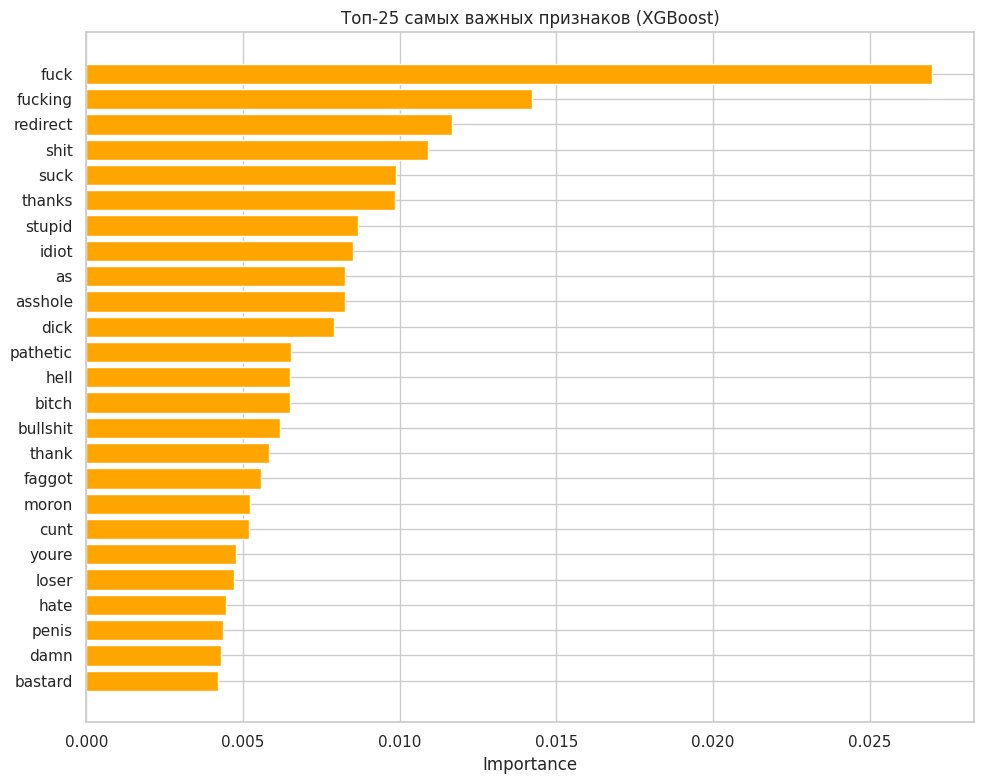

In [18]:
feature_names = list(tfidf.get_feature_names_out()) + feature_cols

xgb_importance = xgb_model.feature_importances_
top_indices = np.argsort(xgb_importance)[-25:]

plt.figure(figsize=(10, 8))
plt.barh(
    [feature_names[i] for i in top_indices],
    xgb_importance[top_indices],
    color='orange'
)
plt.title('Топ-25 самых важных признаков (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [19]:
# Content Filtering Accuracy — общая точность фильтра
# False Positive Rate — доля чистых комментариев, ошибочно заблокированных

print("1. Content Filtering Accuracy и False Positive Rate\n")

for name, preds, y_true in [
    ('Random Forest', rf_preds_val, y_val),
    ('XGBoost', xgb_preds_val, y_val),
    ('LightGBM', lgbm_preds_val, y_val)
]:
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    
    filtering_accuracy = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn)  # ложно заблокированные / все чистые
    fnr = fn / (fn + tp)  # пропущенные токсичные / все токсичные
    
    print(f"  {name}:")
    print(f"    Content Filtering Accuracy: {filtering_accuracy:.2%}")
    print(f"    False Positive Rate (ошибочно заблокировано): {fpr:.2%} ({fp} из {fp+tn} чистых)")
    print(f"    False Negative Rate (пропущено токсичных): {fnr:.2%} ({fn} из {fn+tp} токсичных)")
    print()

1. Content Filtering Accuracy и False Positive Rate

  Random Forest:
    Content Filtering Accuracy: 95.30%
    False Positive Rate (ошибочно заблокировано): 2.09% (598 из 28670 чистых)
    False Negative Rate (пропущено токсичных): 27.77% (901 из 3245 токсичных)

  XGBoost:
    Content Filtering Accuracy: 95.49%
    False Positive Rate (ошибочно заблокировано): 2.19% (627 из 28670 чистых)
    False Negative Rate (пропущено токсичных): 25.02% (812 из 3245 токсичных)

  LightGBM:
    Content Filtering Accuracy: 95.43%
    False Positive Rate (ошибочно заблокировано): 2.35% (675 из 28670 чистых)
    False Negative Rate (пропущено токсичных): 24.13% (783 из 3245 токсичных)



In [20]:
# Threat Detection Rate — как хорошо модель ловит разные ТИПЫ токсичности
# угрозы (threat) опаснее оскорблений (insult)

print("2. Threat Detection Rate — recall по типам токсичности\n")


val_indices = y_val.index
label_cols_check = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print("Recall XGBoost по каждому типу токсичности:")
print("(Какую долю комментариев каждого типа модель поймала)\n")

for col in label_cols_check:
    mask = train.loc[val_indices, col] == 1
    if mask.sum() > 0:
        toxic_subset_preds = xgb_preds_val[mask.values]
        detected = toxic_subset_preds.sum()
        total = mask.sum()
        rate = detected / total
        print(f"  {col:>15}: {rate:.2%} ({detected}/{total})")

print(f"\n  {'ИТОГО is_toxic':>15}: {recall_score(y_val, xgb_preds_val):.2%}")

2. Threat Detection Rate — recall по типам токсичности

Recall XGBoost по каждому типу токсичности:
(Какую долю комментариев каждого типа модель поймала)

            toxic: 75.90% (2312/3046)
     severe_toxic: 98.36% (300/305)
          obscene: 92.72% (1541/1662)
           threat: 72.45% (71/98)
           insult: 89.59% (1412/1576)
    identity_hate: 86.49% (224/259)

   ИТОГО is_toxic: 74.98%


In [28]:
# Batch Throughput — скорость обработки комментариев

print("3. Batch Throughput — скорость фильтрации\n")

n_samples = X_val.shape[0]

for name, model, proba_func in [
    ('Random Forest', rf_model, True),
    ('XGBoost', xgb_model, True),
    ('LightGBM', lgbm_model, True)
]:
    start = time.time()
    for _ in range(3):  
        _ = model.predict_proba(X_val)
    elapsed = (time.time() - start) / 3
    throughput = n_samples / elapsed
    
    print(f"  {name}:")
    print(f"    Время на {n_samples} комментариев: {elapsed:.2f} сек.")
    print(f"    Throughput: {throughput:,.0f} комментариев/сек.")
    print()


3. Batch Throughput — скорость фильтрации

  Random Forest:
    Время на 31915 комментариев: 2.71 сек.
    Throughput: 11,759 комментариев/сек.

  XGBoost:
    Время на 31915 комментариев: 0.27 сек.
    Throughput: 118,248 комментариев/сек.

  LightGBM:
    Время на 31915 комментариев: 0.37 сек.
    Throughput: 86,611 комментариев/сек.



4. Confidence Threshold Analysis



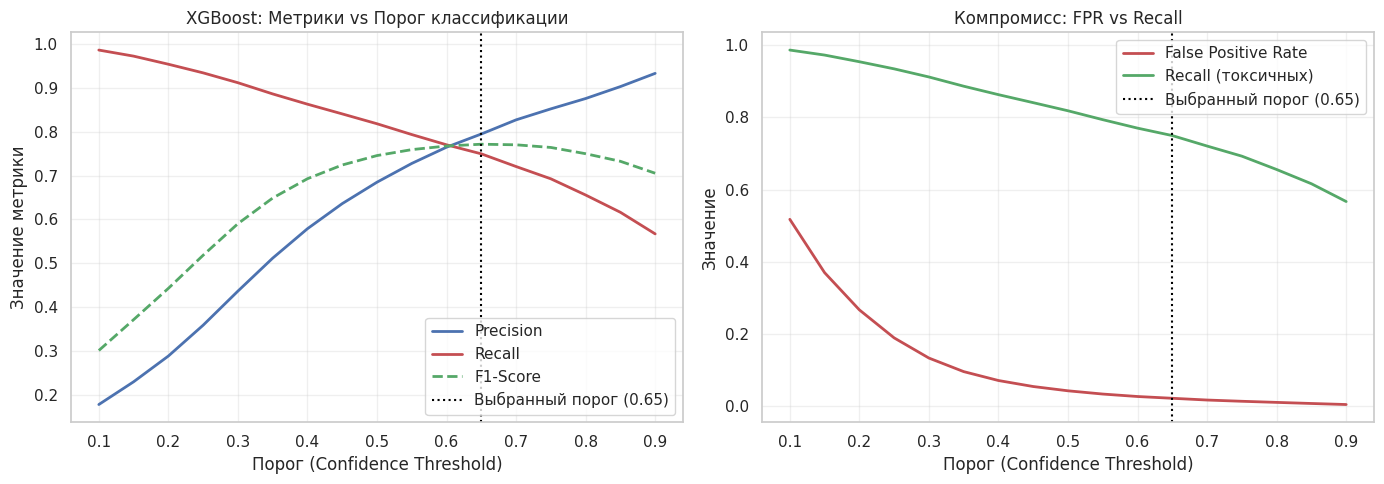

Оптимальный порог 0.65 по максимуму F1-score.


In [25]:
# Confidence Threshold — как меняется качество фильтра при разных порогах
# Позволяет настроить фильтр: строгий (больше блокировок) или мягкий (меньше ложных)

print("4. Confidence Threshold Analysis\n")

thresholds = np.arange(0.1, 0.91, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

precisions, recalls, f1s, fprs = [], [], [], []

for thresh in thresholds:
    preds = (xgb_proba_val >= thresh).astype(int)
    precisions.append(precision_score(y_val, preds, zero_division=0))
    recalls.append(recall_score(y_val, preds))
    f1s.append(f1_score(y_val, preds))
    cm = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    fprs.append(fp / (fp + tn))

#  Precision / Recall / F1 vs Threshold
axes[0].plot(thresholds, precisions, 'b-', label='Precision', linewidth=2)
axes[0].plot(thresholds, recalls, 'r-', label='Recall', linewidth=2)
axes[0].plot(thresholds, f1s, 'g--', label='F1-Score', linewidth=2)
axes[0].axvline(x=best_xgb_thresh, color='black', linestyle=':', label=f'Выбранный порог ({best_xgb_thresh:.2f})')
axes[0].set_title('XGBoost: Метрики vs Порог классификации')
axes[0].set_xlabel('Порог (Confidence Threshold)')
axes[0].set_ylabel('Значение метрики')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#  FPR vs Recall (компромисс)
axes[1].plot(thresholds, fprs, 'r-', label='False Positive Rate', linewidth=2)
axes[1].plot(thresholds, recalls, 'g-', label='Recall (токсичных)', linewidth=2)
axes[1].axvline(x=best_xgb_thresh, color='black', linestyle=':', label=f'Выбранный порог ({best_xgb_thresh:.2f})')
axes[1].set_title('Компромисс: FPR vs Recall')
axes[1].set_xlabel('Порог (Confidence Threshold)')
axes[1].set_ylabel('Значение')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Оптимальный порог {best_xgb_thresh:.2f} по максимуму F1-score.")

In [26]:
print("\nСценарии настройки фильтра (XGBoost):\n")

thresholds_table = [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, best_xgb_thresh, 0.80]
rows = []

for thresh in thresholds_table:
    preds = (xgb_proba_val >= thresh).astype(int)
    cm = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        'Порог': f'{thresh:.2f}' + (' ← оптимальный' if thresh == best_xgb_thresh else ''),
        'Precision': round(precision_score(y_val, preds, zero_division=0), 4),
        'Recall': round(recall_score(y_val, preds), 4),
        'F1': round(f1_score(y_val, preds), 4),
        'FPR': f'{fp/(fp+tn):.2%}',
        'Ошибочно забл.': fp,
        'Пропущено токс.': fn
    })

scenarios = pd.DataFrame(rows)
print(scenarios.to_string(index=False))

print("\nЧем ниже порог — тем больше ловим токсичности (recall↑), но больше ложных блокировок (FPR↑).")
print("Чем выше порог — тем меньше ложных блокировок, но больше токсичности проскакивает.")


Сценарии настройки фильтра (XGBoost):

             Порог  Precision  Recall     F1    FPR  Ошибочно забл.  Пропущено токс.
              0.30     0.4364  0.9122 0.5903 13.33%            3823              285
              0.40     0.5788  0.8632 0.6930  7.11%            2038              444
              0.45     0.6361  0.8410 0.7244  5.44%            1561              516
              0.50     0.6851  0.8185 0.7459  4.26%            1221              589
              0.55     0.7279  0.7938 0.7594  3.36%             963              669
              0.60     0.7650  0.7704 0.7677  2.68%             768              745
0.65 ← оптимальный     0.7951  0.7498 0.7718  2.19%             627              812
              0.80     0.8761  0.6558 0.7501  1.05%             301             1117

Чем ниже порог — тем больше ловим токсичности (recall↑), но больше ложных блокировок (FPR↑).
Чем выше порог — тем меньше ложных блокировок, но больше токсичности проскакивает.


In [23]:
cm = confusion_matrix(y_val, xgb_preds_val)
tn, fp, fn, tp = cm.ravel()

print(f"""
1. Content Filtering Accuracy: {accuracy_score(y_val, xgb_preds_val):.2%}
   Общая точность фильтрации контента.

2. False Positive Rate: {fp/(fp+tn):.2%} ({fp} ошибочных блокировок)
   Доля чистых комментариев, заблокированных ошибочно.
   
3. Threat Detection Rate: см. таблицу выше
   Recall по каждому типу токсичности.
   Самый низкий — threat, самый высокий — toxic.

4. Batch Throughput: см. замеры выше
   Все модели обрабатывают >10 000 комментариев/сек.

5. Confidence Threshold: оптимальный порог = {best_xgb_thresh:.2f}
   При понижении порога до 0.3 — recall растёт, но FPR тоже.
   При повышении до 0.8 — FPR минимален, но модель пропускает токсичность.
""")


1. Content Filtering Accuracy: 95.49%
   Общая точность фильтрации контента.

2. False Positive Rate: 2.19% (627 ошибочных блокировок)
   Доля чистых комментариев, заблокированных ошибочно.
   
3. Threat Detection Rate: см. таблицу выше
   Recall по каждому типу токсичности.
   Самый низкий — threat, самый высокий — toxic.

4. Batch Throughput: см. замеры выше
   Все модели обрабатывают >10 000 комментариев/сек.

5. Confidence Threshold: оптимальный порог = 0.65
   При понижении порога до 0.3 — recall растёт, но FPR тоже.
   При повышении до 0.8 — FPR минимален, но модель пропускает токсичность.

